# Module: Region Similarity

Assuming that transcripts are homogeneously distributed throughout the cell,
we expect there to be similar expression of genes in the nucleus and in the rest of the cell.
If this is not the case, it can be indicative of transcript spillover from adjacent cells.

<center>
 <img src='../_static/img/docs/region_similarity.png' width='90%' />
</center>

The `region similarity` (`rs`) module compares transcript composition between different
subcellular regions to identify cells with unexpected spatial differences in expression.

Because profiles with fewer transcripts are inherently more variable and therefore tend to appear
less similar even when sampled from the same underlying expression profile, SegTraQ accounts for
this finite-count effect using a permutation-based expectation. The reported scores measure
similarity relative to this expectation: values around zero indicate the expected level of similarity,
negative values indicate lower similarity than expected, and positive values indicate higher
similarity than expected. The accompanying p-value identifies cells with unusually low similarity.

To follow along with this tutorial, you can download the data from
[here](https://oc.embl.de/index.php/s/YSvZTt8AArh4c5a).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa
from scipy.stats import linregress

import segtraq

segtraq.settings.n_jobs = -1  # Use all available CPU cores

/g/huber/users/lazic/src/SegTraQ/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Helpers

In [3]:
# helper functions for plotting
def plot_histogram(
    df,
    column,
    bins=30,
    figsize=(6, 5),
    color="steelblue",
    edgecolor="black",
    show_median=True,
    median_kwargs=None,
    median_color="red",
    title=None,
    xlabel=None,
    ylabel="Count",
    ax=None,
):
    values = df[column].dropna()
    median_value = np.median(values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    ax.hist(values, bins=bins, color=color, edgecolor=edgecolor)

    if show_median:
        median_kwargs = median_kwargs or {}
        ax.axvline(
            median_value,
            linestyle="--",
            linewidth=2,
            color=median_color,
            label=f"Median = {median_value:.2f}",
            **median_kwargs,
        )
        ax.legend()

    ax.set_title(title or f"Distribution of {column}")
    ax.set_xlabel(xlabel or column)
    ax.set_ylabel(ylabel)

    plt.show()


def plot_regression(
    df,
    x,
    y,
    figsize=(6, 6),
    dropna=True,
    ci=95,
    scatter_kws=None,
    line_kws=None,
    title=None,
    xlabel=None,
    ylabel=None,
    r2_loc=(0.05, 0.95),
    r2_fmt="{:.3f}",
    ax=None,
):
    data = df[[x, y]]
    if dropna:
        data = data.dropna()

    # Regression stats
    slope, intercept, r_value, p_value, std_err = linregress(data[x], data[y])
    r_squared = r_value**2

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    scatter_kws = scatter_kws or {"alpha": 0.6}
    line_kws = line_kws or {"color": "red"}

    sns.regplot(
        data=data,
        x=x,
        y=y,
        ci=ci,
        scatter_kws=scatter_kws,
        line_kws=line_kws,
        ax=ax,
    )

    # R² annotation
    ax.text(
        r2_loc[0],
        r2_loc[1],
        rf"$R^2 = {r2_fmt.format(r_squared)}$",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.set_title(title or f"{y} vs. {x}")
    ax.grid(True)

    plt.show()

We start out by loading the data into a `SegTraQ` object.

In [4]:
sdata = sd.read_zarr("../../data/xenium_v1_data/sdata_xenium_crop.zarr/")
st = segtraq.SegTraQ(
    sdata,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st.sdata

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:162: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: UserWarning: Filtering control probes matching prefixes ('NegControlProbe_', 'antisense_', 'NegControlCodeword', 'BLANK_', 'Blank-', 'NegPrb', 'DeprecatedCodeword_', 'UnassignedCodeword_', 'Intergenic_Region_') and transcripts with qv < 20 from transcript points in-place; control probes are also removed from the expression table if present. Configure `min_qv`, `control_prefixes`, and `inplace` via `filter_kwargs`.
  sdata_new = _filter_control_and_low_quality_transcripts(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:190: RuntimeWarning: Cell IDs differ between assigned transcript points and the expression table. 0 cells occur only in points (e.g. []), and 14 occur only in the table (e.g. [np.int32(94563), np.int32(77508), np.int

SpatialData object, with associated Zarr store: /g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 2500, 2500), (1, 1250, 1250), (1, 625, 625), (1, 313, 313), (1, 156, 156)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1563, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1501, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (1563, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

We can optionally transfer cell-type labels from a scRNA-seq reference. These labels are not required to compute the
`region_similarity` metrics, but help interpret them—for example, by assessing whether low similarity is more common
at boundaries between different cell types.

In [5]:
adata_ref = ad.read_h5ad("../../data/xenium_5K_data/BC_scRNAseq_Janesick.h5ad")

st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_raw_counts_layer="raw", inplace=True)

As you can see, the `spatialdata`dataset contains cell and nuclear masks as `shapes`.
It is important that you have a nuclear segmentation in your object,
otherwise you will not be able to compute the metrics below.

## Intersection over Union between cell and nucleus masks

First, we match each cell to its most overlapping nucleus using `match_nuclei_to_cells()` and quantify
the overlap using the Intersection over Union (`iou`) and `nucleus_fraction`, the fraction of the nucleus
area covered by the cell. These measures can highlight poor morphological segmentation: oversegmented
cells may cover only part of a nucleus, resulting in a low `nucleus_fraction`, whereas undersegmented
cells may extend far beyond the nucleus, resulting in a low `iou`.

In [6]:
results_df = st.rs.match_nuclei_to_cells()
results_df.head()

,cell_id,nucleus_id,iou,nucleus_fraction
0,6327,6327.0,0.051420,1.0
1,6328,6328.0,0.064608,1.0
2,6330,6330.0,0.047572,1.0
3,6331,6331.0,0.042835,1.0
4,6332,6332.0,0.041484,1.0


For each `cell_id`, we obtain the ID (`nucleus_id`) of the nucleus mask with the highest `nucleus_fraction`.
If a cell does not overlap with any nucleus, the function returns a missing value for `nucleus_id`.
If the nucleus has an invalid geometry, `iou` and `nucleus_fraction` are reported as `NA`.

Let's see what this looks like when we plot the `iou` and `nucleus_fraction` spatially.

WARNING  render_shapes: Found 64 NaN values in color data. These observations will be colored with the 'na_color'. 


WARNING  render_shapes: Found 64 NaN values in color data. These observations will be colored with the 'na_color'. 


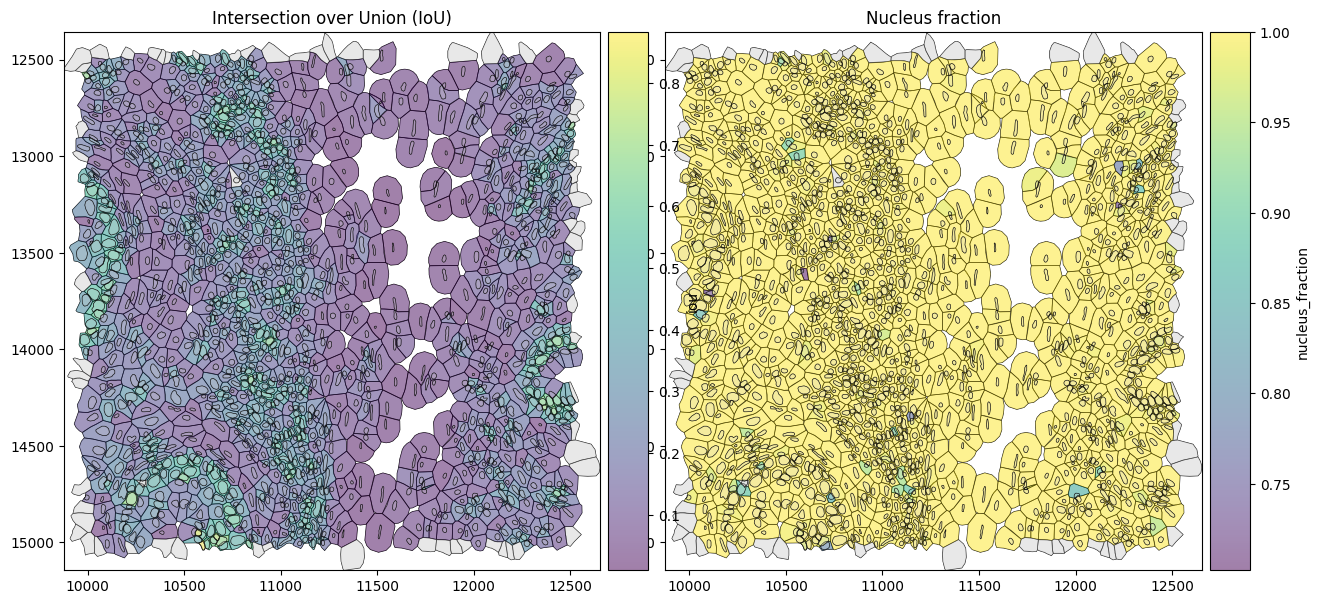

In [7]:
# link annotations with cell boundaries
st.sdata.tables[st.tables_key].obs["region"] = st.shapes_key
st.sdata.set_table_annotates_spatialelement(st.tables_key, region=st.shapes_key)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# IoU
st.sdata.pl.render_shapes(
    element=st.shapes_key,
    color="iou",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element=st.nucleus_shapes_key,
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[0],
    title="Intersection over Union (IoU)",
    colorbar=True,
)

# Nucleus fraction
st.sdata.pl.render_shapes(
    element=st.shapes_key,
    color="nucleus_fraction",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element=st.nucleus_shapes_key,
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[1],
    title="Nucleus fraction",
    colorbar=True,
)

plt.show()

Since the legacy Xenium segmentation algorithm generates cell masks by expanding nuclear boundaries, most cells have a
`nucleus_fraction` close to 1.

We can now investigate what the distribution of IoUs looks like.

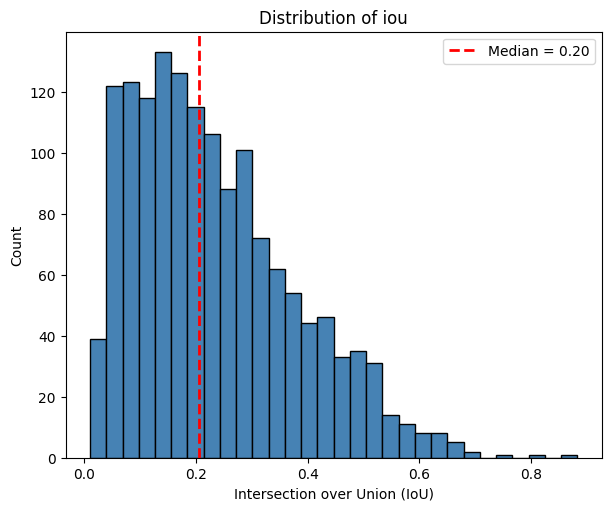

In [8]:
plot_histogram(
    df=sdata[st.tables_key].obs,
    column="iou",
    xlabel="Intersection over Union (IoU)",
)

## Expression similarity between cell and nucleus

While IoU and `nucleus_fraction` assess whether the cell and nucleus are morphologically well matched,
`similarity_nucleus_cell()` asks whether they are also molecularly consistent. It compares the transcript
composition of the whole cell with that of its matched nucleus and determines whether they are less similar
than expected given their transcript counts and overlap. For transcript-informed segmentation methods the whole cell
may also include transcripts beyond morphological boundaries.

A negative residual indicates unexpectedly different transcript compositions, which can arise, for example, when
transcripts from neighboring cells are incorrectly assigned to the cell or when transcripts from the cell are
incorrectly excluded, even if the cell and nucleus boundaries appear well matched.

In [9]:
nucleus_cell_df = st.rs.similarity_nucleus_cell()

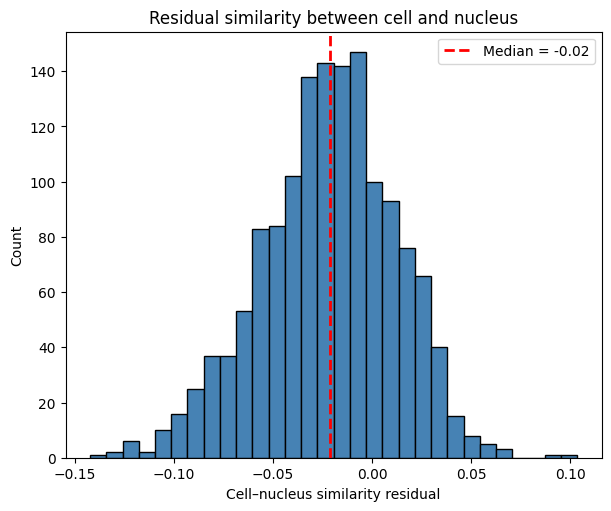

In [10]:
plot_histogram(
    df=sdata[st.tables_key].obs,
    column="similarity_nucleus_cell",
    title="Residual similarity between cell and nucleus",
    xlabel="Cell–nucleus similarity residual",
)

We can visualize the similarity residual spatially to identify cells whose nucleus and whole-cell
transcript profiles are less similar than expected. The residual indicates the magnitude of this
difference, while the p-value indicates how strongly the data support it. Cells with both a negative
residual and a low p-value therefore provide the strongest evidence for unexpectedly different
nucleus–cell transcript composition.

WARNING  render_shapes: Found 64 NaN values in color data. These observations will be colored with the 'na_color'. 


WARNING  render_shapes: Found 127 NaN values in color data. These observations will be colored with the 'na_color'.


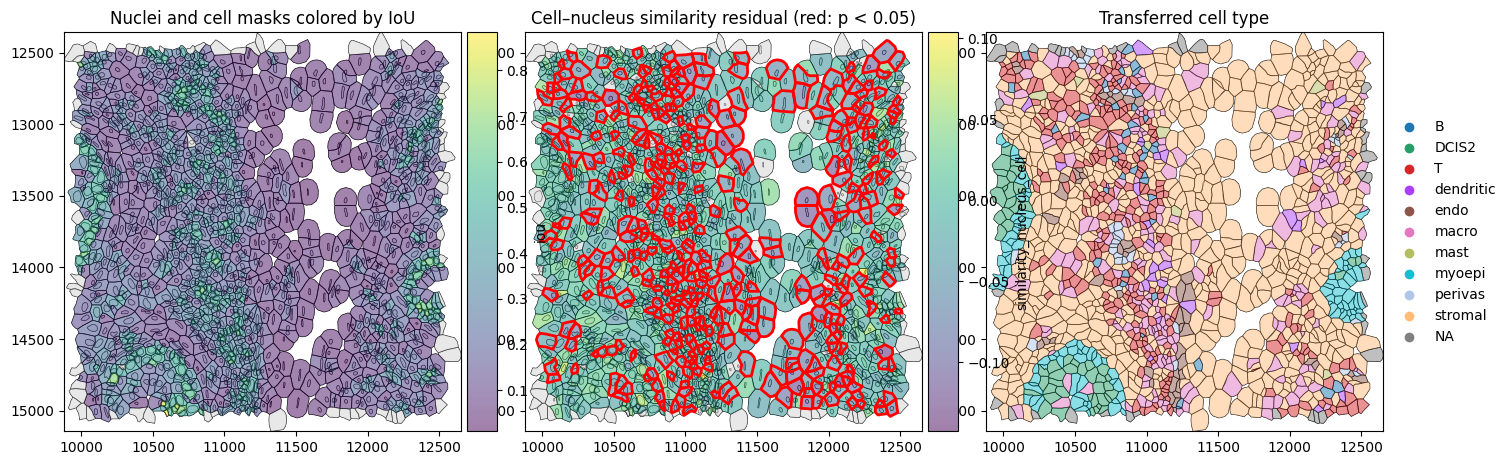

In [11]:
obs = sdata.tables[st.tables_key].obs

# Get significant cell IDs
significant_ids = obs.loc[
    obs["similarity_nucleus_cell_p_value"] < 0.05,
    st.tables_cell_id_key,
]

# Create a temporary shapes element containing only significant cells
sdata.shapes["significant_cells"] = (
    sdata.shapes[st.shapes_key].loc[sdata.shapes[st.shapes_key].index.isin(significant_ids)].copy()
)

# plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# IoU
sdata.pl.render_shapes(
    element=st.nucleus_shapes_key,
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element=st.shapes_key,
    color="iou",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=ax[0],
    title="Nuclei and cell masks colored by IoU",
    colorbar=True,
)

# Cell–nucleus similarity residual
sdata.pl.render_shapes(
    element=st.nucleus_shapes_key,
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element=st.shapes_key,
    color="similarity_nucleus_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="significant_cells",
    fill_alpha=0.0,
    outline_alpha=1.0,
    outline_width=2.0,
    outline_color="red",
).pl.show(
    ax=ax[1],
    title="Cell–nucleus similarity residual (red: p < 0.05)",
    colorbar=True,
)

# Transferred cell type
sdata.pl.render_shapes(
    element=st.shapes_key,
    color="transferred_cell_type",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
    na_color="gray",
).pl.show(
    ax=ax[2],
    title="Transferred cell type",
    colorbar=False,
)

plt.show()

## Similarity between nucleus and cytoplasm

Because nuclear transcripts are part of the whole-cell profile, nucleus–cell similarity is partly driven by
transcripts shared between the two profiles. We therefore also compare the nucleus with the remaining non-nuclear part
of the cell (referred to here as the cytoplasm).

While `similarity_nucleus_cell` evaluates whether the final cell-level expression profile is molecularly consistent
with its matched nucleus, `similarity_nucleus_cytoplasm` provides a more direct comparison of transcript composition
between the two compartments. Low residual values may indicate transcript misassignment or contamination, but can also
reflect genuine subcellular RNA localization.

In [12]:
nuc_cyto_df = st.rs.similarity_nucleus_cytoplasm()
nuc_cyto_df.head()

,cell_id,nucleus_id,iou,nucleus_fraction,similarity_nucleus_cytoplasm,similarity_nucleus_cytoplasm_p_value
0,6327,6327.0,0.051420,1.0,-0.146316,0.004975
1,6328,6328.0,0.064608,1.0,-0.028276,0.308458
2,6330,6330.0,0.047572,1.0,-0.085832,0.039801
3,6331,6331.0,0.042835,1.0,-0.069625,0.049751
4,6332,6332.0,0.041484,1.0,-0.044115,0.159204


The histogram below shows the distribution of nucleus–cytoplasm similarity residuals. For most cells, the observed
similarity is close to that expected under the null model.

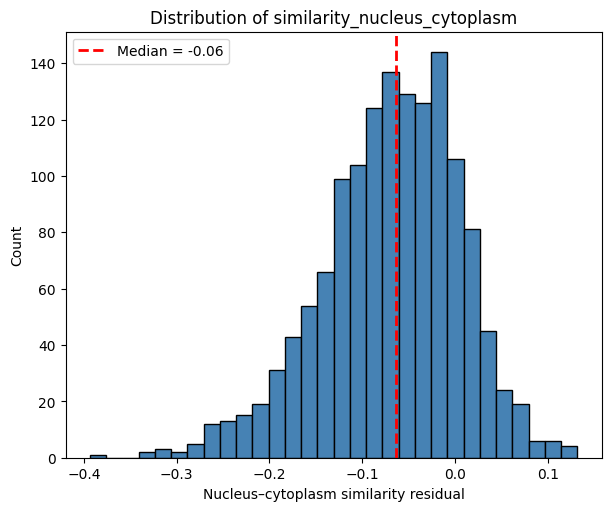

In [13]:
plot_histogram(
    df=sdata[st.tables_key].obs,
    column="similarity_nucleus_cytoplasm",
    xlabel="Nucleus–cytoplasm similarity residual",
)

We can look at the correlation between the `similarity_nucleus_cell` and `similarity_nucleus_cytoplasm`. As expected,
`similarity_nucleus_cell` and `similarity_nucleus_cytoplasm` are strongly correlated, as both capture molecular
differences between the nucleus and the rest of the cell. They can diverge when the nucleus contributes strongly to
the whole-cell profile: even if nucleus and cytoplasm differ substantially, the whole-cell profile may remain similar
to the nucleus because it contains the nuclear transcripts themselves.

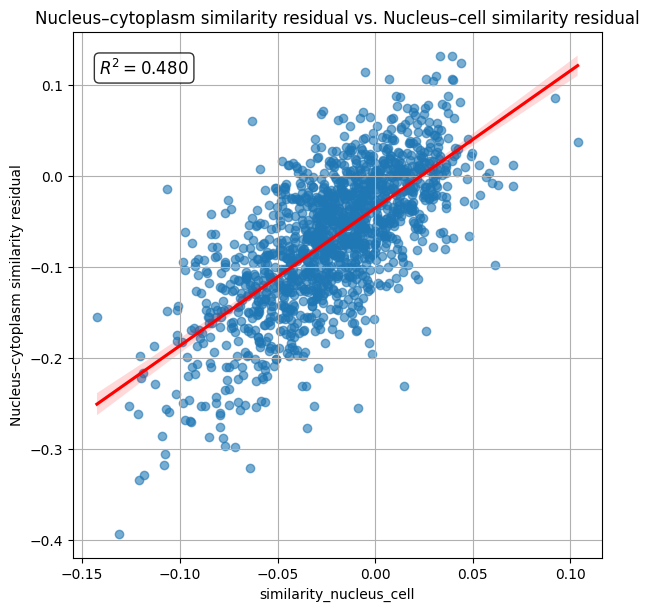

In [14]:
plot_regression(
    df=sdata[st.tables_key].obs,
    x="similarity_nucleus_cell",
    y="similarity_nucleus_cytoplasm",
    title="Nucleus–cytoplasm similarity residual vs. Nucleus–cell similarity residual",
    ylabel="Nucleus–cytoplasm similarity residual",
)

Let's visualize this in a spatial plot.

WARNING  render_shapes: Found 127 NaN values in color data. These observations will be colored with the 'na_color'.


WARNING  render_shapes: Found 143 NaN values in color data. These observations will be colored with the 'na_color'.


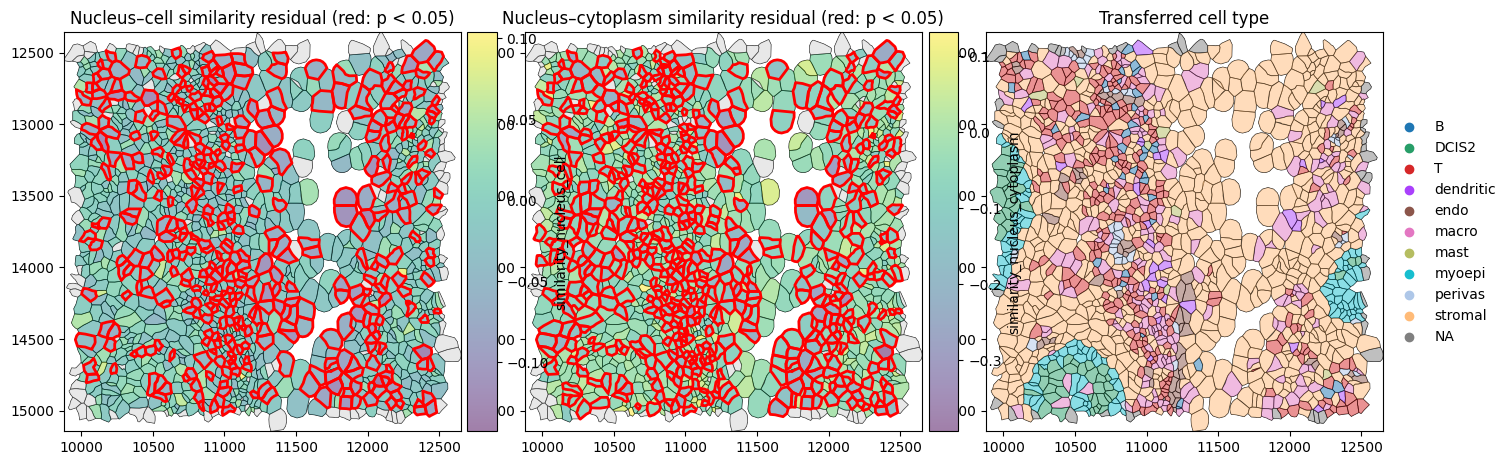

In [15]:
obs = sdata.tables[st.tables_key].obs

# Get significant cell IDs for each similarity metric
significant_nucleus_cell_ids = obs.loc[
    obs["similarity_nucleus_cell_p_value"] < 0.05,
    st.tables_cell_id_key,
]

significant_nucleus_cytoplasm_ids = obs.loc[
    obs["similarity_nucleus_cytoplasm_p_value"] < 0.05,
    st.tables_cell_id_key,
]

# Create temporary shapes elements containing only significant cells
sdata.shapes["significant_nucleus_cell"] = (
    sdata.shapes[st.shapes_key].loc[sdata.shapes[st.shapes_key].index.isin(significant_nucleus_cell_ids)].copy()
)

sdata.shapes["significant_nucleus_cytoplasm"] = (
    sdata.shapes[st.shapes_key].loc[sdata.shapes[st.shapes_key].index.isin(significant_nucleus_cytoplasm_ids)].copy()
)


# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Cell–nucleus similarity residual
sdata.pl.render_shapes(
    element=st.shapes_key,
    color="similarity_nucleus_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="significant_nucleus_cell",
    fill_alpha=0.0,
    outline_alpha=1.0,
    outline_width=2.0,
    outline_color="red",
).pl.show(
    ax=ax[0],
    title="Nucleus–cell similarity residual (red: p < 0.05)",
    colorbar=True,
)

# Nucleus–cytoplasm similarity residual
sdata.pl.render_shapes(
    element=st.shapes_key,
    color="similarity_nucleus_cytoplasm",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="significant_nucleus_cytoplasm",
    fill_alpha=0.0,
    outline_alpha=1.0,
    outline_width=2.0,
    outline_color="red",
).pl.show(
    ax=ax[1],
    title="Nucleus–cytoplasm similarity residual (red: p < 0.05)",
    colorbar=True,
)

# Transferred cell type
sdata.pl.render_shapes(
    element=st.shapes_key,
    color="transferred_cell_type",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
    na_color="gray",
).pl.show(
    ax=ax[2],
    title="Transferred cell type",
    colorbar=False,
)

plt.show()

We observe more cells with significantly reduced `similarity_nucleus_cytoplasm` than `similarity_nucleus_cell`,
particularly in regions with heterogeneous cell-type composition.

## Border admixture score

A cell's border can differ from its center for many reasons, including genuine intracellular RNA localization.
Therefore, low center–border similarity alone does not show that neighboring cells contributed to that difference.

The `border_admixture_score()` tests this more directly by asking whether the border is better explained as a mixture
of the cell center and its neighborhood:

$$
p_{\text{border}} \approx (1 - \alpha)\,p_{\text{center}}
+ \alpha\,p_{\text{neighborhood}}
$$

The observed admixture score measures how much better this mixture explains the border compared with
the center alone. Because some apparent admixture can arise simply from finite transcript sampling,
SegTraQ subtracts the mean score expected under a permutation null. The reported
`border_admixture_score` therefore reflects **excess neighborhood-like admixture beyond
what is expected by chance**.

Values around zero are close to the null expectation, while positive residuals indicate stronger
neighborhood contribution than expected. The accompanying upper-tail p-value identifies cells with
unusually strong admixture.

In [16]:
st.rs.border_admixture_score()

,cell_id,border_admixture_score,border_admixture_p_value
0,6327,0.144494,0.084577
1,6328,0.248748,0.029851
2,6330,-0.121840,0.920398
3,6331,0.397265,0.004975
4,6332,0.027329,0.328358
...,...,...,...
1557,95953,0.439227,0.004975
1558,95954,0.228213,0.004975
1559,95955,0.007347,0.273632
1560,95959,0.191630,0.004975


The histogram below shows the distribution of the border_admixture_score.

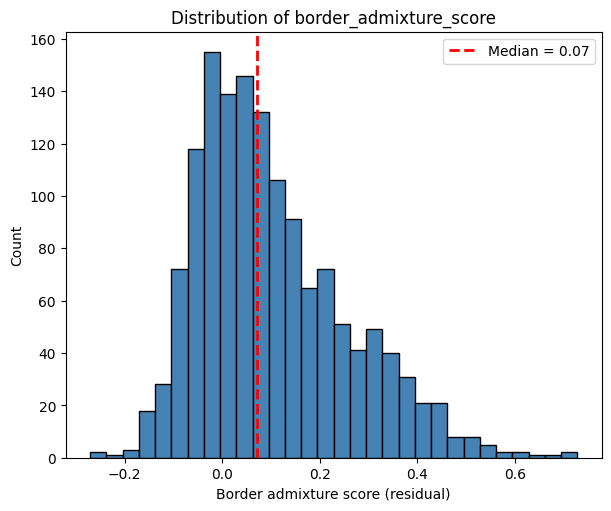

In [17]:
plot_histogram(
    df=sdata[st.tables_key].obs,
    column="border_admixture_score",
    xlabel="Border admixture score (residual)",
)

WARNING  render_shapes: Found 127 NaN values in color data. These observations will be colored with the 'na_color'.


WARNING  render_shapes: Found 132 NaN values in color data. These observations will be colored with the 'na_color'.


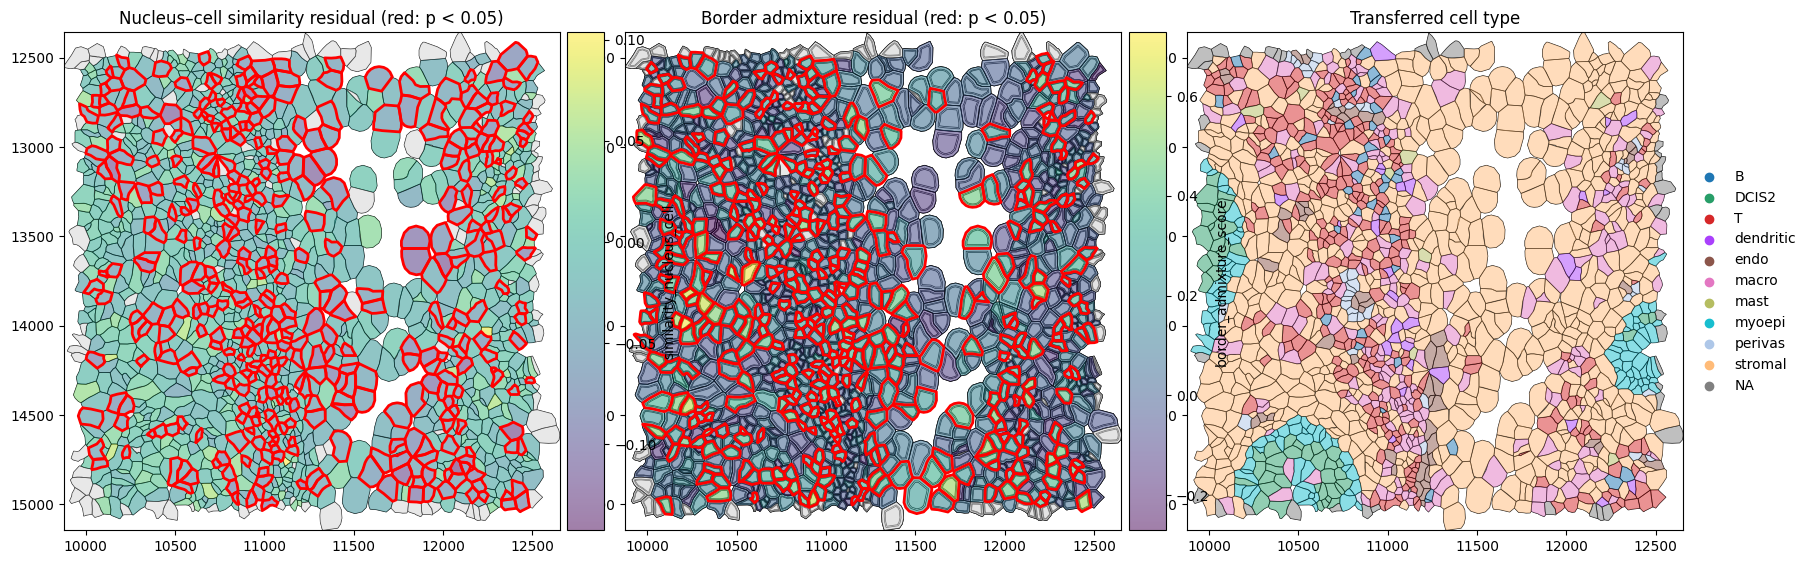

In [18]:
obs = sdata.tables[st.tables_key].obs

# Get significant cell IDs for nucleus-cell similarity
significant_nucleus_cell_ids = obs.loc[
    obs["similarity_nucleus_cell_p_value"] < 0.05,
    st.tables_cell_id_key,
]

# Get significant cell IDs for border admixture
significant_border_admixture_ids = obs.loc[
    obs["border_admixture_p_value"] < 0.05,
    st.tables_cell_id_key,
]

# Create temporary shapes elements containing significant cells
sdata.shapes["significant_nucleus_cell"] = (
    sdata.shapes[st.shapes_key].loc[sdata.shapes[st.shapes_key].index.isin(significant_nucleus_cell_ids)].copy()
)

sdata.shapes["significant_border_admixture"] = (
    sdata.shapes[st.shapes_key].loc[sdata.shapes[st.shapes_key].index.isin(significant_border_admixture_ids)].copy()
)

# Link annotations with cell boundaries
obs["region"] = st.shapes_key
sdata.set_table_annotates_spatialelement(
    st.tables_key,
    region=st.shapes_key,
)

# Plot
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    constrained_layout=True,
)

# 1. Nucleus-cell similarity residual
sdata.pl.render_shapes(
    element=st.shapes_key,
    color="similarity_nucleus_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="significant_nucleus_cell",
    fill_alpha=0.0,
    outline_alpha=1.0,
    outline_width=2.0,
    outline_color="red",
).pl.show(
    ax=axes[0],
    title="Nucleus–cell similarity residual (red: p < 0.05)",
    colorbar=True,
)

# 2. Border admixture residual
sdata.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_borders",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element=st.shapes_key,
    color="border_admixture_score",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="significant_border_admixture",
    fill_alpha=0.0,
    outline_alpha=1.0,
    outline_width=2.0,
    outline_color="red",
).pl.show(
    ax=axes[1],
    title="Border admixture residual (red: p < 0.05)",
    colorbar=True,
)

# 3. Transferred cell type
sdata.pl.render_shapes(
    element=st.shapes_key,
    color="transferred_cell_type",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
    na_color="gray",
).pl.show(
    ax=axes[2],
    title="Transferred cell type",
    colorbar=False,
)

plt.show()

For convenience, `SegTraQ` also provides a wrapper to run all `region_similarity` metrics.

In [19]:
sdata = sd.read_zarr("../../data/xenium_v1_data/sdata_xenium_crop.zarr/")
st = segtraq.SegTraQ(
    sdata,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st.run_region_similarity()

st.sdata.tables[st.tables_key].obs.columns

Index(['cell_id', 'transcript_counts', 'control_probe_counts',
       'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area',
       'region', 'centroid_x', 'centroid_y', 'similarity_nucleus_cell',
       'similarity_nucleus_cell_p_value', 'nucleus_id', 'iou',
       'nucleus_fraction', 'similarity_nucleus_cytoplasm',
       'similarity_nucleus_cytoplasm_p_value', 'border_admixture_score',
       'border_admixture_p_value'],
      dtype='object')

## Session Info

In [20]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.8.0
0.4.0
